### Set Up

In [1]:
import numpyro
numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp
import numpy as np
import sncosmo
from bayesn import SEDmodel
from pathlib import Path
import pandas as pd

from io import BytesIO
import gzip
from astropy.io import fits
from zipfile import ZipFile, BadZipFile

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from bayesn import SEDmodel

In [14]:
from io import BytesIO
import gzip
from astropy.io import fits
from pathlib import Path


lsst_zip = Path(
    "/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/LSST_ALERTS.zip"
)
head_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_HEAD.FITS.gz"
phot_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_PHOT.FITS.gz"
readme_name = "LSST_ALERTS/LSST/LSST.README"

# Bits used
DETECTION_BIT = 1
GARBAGE_BIT = 64
VALID_BANDS = np.array(list("ugrizy"))

#print("Working directory:". Path.cwd())
print("Archive path:", lsst_zip.resolve())

Archive path: /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/LSST_ALERTS.zip


In [15]:
if not lsst_zip.exists():
    raise FileNotFoundError(f"LSST archive not found: {lsst_zip.resolve()}")
    
try:
    with ZipFile(lsst_zip, "r") as archive:
        names = archive.namelist()
        print(f"Archive entries: {len(names):,}")
        print("\n".join(names[:30]))
except BadZipFile as exc:
    raise BadZipFile(f"Not a valid ZIP archive: {lsst_zip}") from exc



Archive entries: 67
LSST_ALERTS/
LSST_ALERTS/LSST/
LSST_ALERTS/TABLE.GARBAGE
LSST_ALERTS/TEXT_archive/
LSST_ALERTS/SUBMIT.INFO
LSST_ALERTS/.DS_Store
__MACOSX/LSST_ALERTS/._.DS_Store
LSST_ALERTS/MERGE.LOG
LSST_ALERTS/TABLE.SNIDALL
LSST_ALERTS/SCRIPTS_MKDATA.tar.gz
LSST_ALERTS/LSST_CHUNK01/
LSST_ALERTS/ALL.DONE
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT010_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT005_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT002_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT007_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT003_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT004_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT006_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST.README
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT009_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT008_HEAD.FITS.gz
LSST_ALERTS/LSST/LSST.IGNORE
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT008_PHOT.FITS.gz
LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT009_PHOT.FITS.gz
LSST_AL

In [18]:
with ZipFile(lsst_zip, "r") as archive:
    readme_text = archive.read(readme_name).decode("utf-8", errors = "replace")

print(readme_text[:5000])

DOCUMENTATION: 
  PURPOSE:                   transient lightcurve data files for analysis 
  SOURCE_LSST_FASTDB:        True 
  SURVEY:                    LSST 
  FORMAT:                    FITS 
  USERNAME:                  kessler 
  PHOTFLAG_DETECT:           1 
  # 
  # [___]  @![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]
  PHOTFLAG_GARBAGE:          64 
  NEVT_GARBAGE_ALL:          4472 
  NEVT_GARBAGE_RADEC:        0 
  NEVT_GARBAGE_FLUX_NOTFLOAT:  29 
  NEVT_GARBAGE_FLUX_ZERO:    4443 
  # [___]  @![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]/@![#$)%^&*("?]
  # 
  NEVT_PROCESS_ALL:          501084 
  NEVT_WRITE_ALL:            501084 
  NEVT_WRITE_HOST_ZSPEC:     0 
  NEVT_WRITE_HOST_ZPHOT:     0 
  NEVT_WRITE_SPECTRA:        0 
  NEVT_REJECT:               0 
  NEVT_WRITE_BY_FIELD(WFD):  451593 
  NEVT_WRITE_BY_FIELD(DDF):  49491 
  WALLTIME:                  15.97  # minutes 
  ABORT_IF_ZERO:             429 
DOCUMENTATION_END: 



### Load + Helpers

In [21]:
def read_gzipped_fits_table(archive: ZipFile, member_name: str):
    """Helper for gzip files"""
    raw = gzip.decompress(archive.read(member_name))
    with fits.open(BytesIO(raw), memmap = False) as hdul:
        data = hdul[1].data.copy()
        columns = list(hdul[1].columns.names)
    return data, columns

with ZipFile(lsst_zip, "r") as archive:
    head_data, head_columns = read_gzipped_fits_table(archive, head_name)
    phot_data, phot_columns = read_gzipped_fits_table(archive, phot_name)

print(f"Head objects: {len(head_data):,}")
print(f"Phot rows: {len(phot_data):,}")
print("\nHead columns:", head_columns)
print("\nPhot columns", phot_columns)

Head objects: 51,000
Phot rows: 273,660

Head columns: ['SNID', 'NAME_IAUC', 'NAME_TRANSIENT', 'FAKE', 'MASK_FLUXCOR_SNANA', 'RA', 'DEC', 'PIXSIZE', 'NXPIX', 'NYPIX', 'SNTYPE', 'NOBS', 'PTROBS_MIN', 'PTROBS_MAX', 'MWEBV', 'MWEBV_ERR', 'REDSHIFT_HELIO', 'REDSHIFT_HELIO_ERR', 'REDSHIFT_FINAL', 'REDSHIFT_FINAL_ERR', 'REDSHIFT_QUALITYFLAG', 'MASK_REDSHIFT_SOURCE', 'VPEC', 'VPEC_ERR', 'LENSDMU', 'LENSDMU_ERR', 'HOSTGAL_NMATCH', 'HOSTGAL_NMATCH2', 'HOSTGAL_OBJID', 'HOSTGAL_FLAG', 'HOSTGAL_PHOTOZ', 'HOSTGAL_PHOTOZ_ERR', 'HOSTGAL_SPECZ', 'HOSTGAL_SPECZ_ERR', 'HOSTGAL_RA', 'HOSTGAL_DEC', 'HOSTGAL_SNSEP', 'HOSTGAL_DDLR', 'HOSTGAL_CONFUSION', 'HOSTGAL_LOGMASS', 'HOSTGAL_LOGMASS_ERR', 'HOSTGAL_LOGSFR', 'HOSTGAL_LOGSFR_ERR', 'HOSTGAL_LOGsSFR', 'HOSTGAL_LOGsSFR_ERR', 'HOSTGAL_COLOR', 'HOSTGAL_COLOR_ERR', 'HOSTGAL_ELLIPTICITY', 'HOSTGAL_OBJID2', 'HOSTGAL_SQRADIUS', 'HOSTGAL_OBJID_UNIQUE', 'HOSTGAL_MAG_u', 'HOSTGAL_MAG_g', 'HOSTGAL_MAG_r', 'HOSTGAL_MAG_i', 'HOSTGAL_MAG_z', 'HOSTGAL_MAG_y', 'HOSTGAL_MA

In [28]:
def clean_snid(value) -> str:
    """Return SNID as python string"""
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace").strip()
    return str(value).strip()

def get_lightcurve(head_row, phot_table=phot_data):
    """ Extract phot rows for one object using SNANA pointers """
    start = int(head_row["PTROBS_MIN"]) - 1
    stop = int(head_row["PTROBS_MAX"])
    expected = int(head_row["NOBS"])

    lc = phot_table[start:stop]
    if len(lc) != expected:
        raise ValueError(
            f"SNID {clean_snid(head_row['SNID'])}: expected {expected} rows,"
            f"but pointer range returned {len(lc)}."
        )
    return lc

    

### Photometric Quality Mask

In [60]:
def photometry_mask(lc, *, detections_only=False):
    """ Mask for one object phot
    Keeps: finite MJD, FLUXCAL, and FLUXCALERR
    FLUXCALERR > 0
    real lsst band (removes separator)
    no garbage 64 bit

    if detections_only = True, ony allow detectin bit = 1
    """
    mjd = np.asarray(lc["MJD"], dtype=float)
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flag = np.asarray(lc["PHOTFLAG"], dtype=int)

    mask = (
        np.isfinite(mjd)
        & np.isfinite(flux)
        & np.isfinite(fluxerr)
        & (fluxerr > 0)
        & np.isin(band, VALID_BANDS)
        & ((flag & GARBAGE_BIT) == 0)
    )

    if detections_only:
        mask &= (flag & DETECTION_BIT) != 0

    return mask


def mask_report(lc):
    """Diagnosgic summary of quality mask"""

    flag = np.asarray(lc["PHOTFLAG"], dtype=int)

    good = photometry_mask(lc)
    detections = photometry_mask(lc, detections_only = True)
    return {
        "raw_rows": len(lc),
        "good_rows": int(good.sum()),
        "detections": int(detections.sum()),
        "garbage_rows": int(((flag & GARBAGE_BIT) != 0).sum()),
    }

In [70]:
NIGHTLY_DTYPE = [
    ("MJD", float),
    ("BAND", "U1"),
    ("FLUX", float),
    ("FLUXERR", float),
    ("N_EXP", int),
]

def make_nightly_lightcurve(lc):
    """Using Inverse-Variance to combine multi obs into one per night per band"""
    good = photometry_mask(lc)
    if not np.any(good):
        return np.asarray([], dtype=NIGHTLY_DTYPE)

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)
    night_id = np.floor(mjd).astype(int)

    records = []
    for current_band in np.unique(band[good]):
        band_good = good & (band == current_band)
        for night in np.unique(night_id[band_good]):
            use = band_good & (night_id == night)
            weights = 1.0 / fluxerr[use] ** 2
            wsum = weights.sum()

            records.append((
                np.sum(weights * mjd[use]) / wsum,
                current_band,
                np.sum(weights * flux[use]) / wsum,
                np.sqrt(1.0 / wsum),
                int(use.sum()),
            ))

    return np.array(records, dtype=NIGHTLY_DTYPE)
    
    

In [71]:
def valid_redshift(value) -> bool:
    value = float(value)
    return np.isfinite(value) and value > 0


def summarise_object(row, phot_table=phot_data):
    lc = get_lightcurve(row, phot_table)
    good = photometry_mask(lc)
    detection = photometry_mask(lc, detections_only=True)

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))

    clean_mjd = mjd[good]
    clean_band = band[good]

    return {
        "SNID": clean_snid(row["SNID"]),
        "SNTYPE": int(row["SNTYPE"]),
        "NOBS": int(row["NOBS"]),
        "N_CLEAN": int(good.sum()),
        "N_DETECT": int(detection.sum()),
        "N_BANDS": int(np.unique(clean_band).size),
        "N_NIGHTS": int(np.unique(np.floor(clean_mjd)).size) if clean_mjd.size else 0,
        "TIME_SPAN": float(np.ptp(clean_mjd)) if clean_mjd.size > 1 else 0.0,
        "HAS_REDSHIFT": valid_redshift(row["REDSHIFT_FINAL"]),
    }


summary = pd.DataFrame(summarise_object(row) for row in head_data)
summary.head()

,SNID,SNTYPE,NOBS,N_CLEAN,N_DETECT,N_BANDS,N_NIGHTS,TIME_SPAN,HAS_REDSHIFT
0,00000533-33a2-42cf-bfa4-e4951522102f,0,2,2,2,1,2,4.0419,False
1,00001b7e-822c-4030-9b16-cf9cdca02319,0,2,2,2,1,2,30.9735,False
2,00001dd3-dcbc-436f-99d8-5f310e2212ba,0,2,2,2,1,2,10.0075,False
3,00004f91-a3cc-4f46-912b-df70ebb4c131,0,2,2,2,1,2,11.9482,False
4,00005c75-321d-47a7-ad59-9abf192e251b,0,2,2,2,1,2,8.0208,False


### Further Cuts to find candidates with usable data 

In [73]:
SELECTION = {
    # tweak
    "min_clean": 8, # minimum clean photometric measurements 
    # (individual phot rows passing photometry_mask
    "min_detections": 3,
    "min_bands": 2,
    "min_nights": 5,
    "min_time_span_days": 8,
}

# currently require all, can change
candidate_mask = (
    (summary["N_CLEAN"] >= SELECTION["min_clean"])
    & (summary["N_DETECT"] >= SELECTION["min_detections"])
    & (summary["N_BANDS"] >= SELECTION["min_bands"])
    & (summary["N_NIGHTS"] >= SELECTION["min_nights"])
    & (summary["TIME_SPAN"] >= SELECTION["min_time_span_days"])
)

summary["PASS_MASK"] = candidate_mask
candidates = (
    summary.loc[candidate_mask]
    .sort_values(["N_NIGHTS", "N_BANDS", "N_DETECT", "TIME_SPAN"], ascending=False)
    .reset_index(drop=True)
)

print(f"Objects passing: {candidate_mask.sum():,} / {len(candidate_mask):,} "
      f"({100 * candidate_mask.mean():.2f}%)")

display(candidates.head(20))
    

Objects passing: 2,278 / 51,000 (4.47%)


,SNID,SNTYPE,NOBS,N_CLEAN,N_DETECT,N_BANDS,N_NIGHTS,TIME_SPAN,HAS_REDSHIFT,PASS_MASK
0,a3f7ac57-349f-44a8-bc11-dd101444ace1,0,149,149,125,6,66,180.6791,False,True
1,14c2643a-48e6-4bae-a2e0-20b41cdbefaf,0,157,157,110,6,65,180.6779,False,True
2,23af3b06-9c88-44d8-a6c2-39a062326bbf,0,147,147,134,6,64,180.7016,False,True
3,1ee3563b-4982-460e-8a6f-f609d50f62c9,0,142,142,110,6,62,176.6518,False,True
4,28ea9e0f-cd86-4b7e-becb-9970dd7a006c,0,142,142,118,6,60,175.6530,False,True
5,c277a753-263d-45cf-914f-cc97dce31425,0,132,132,128,6,59,164.7465,False,True
6,d1a059cd-5fd8-4b2d-a93d-cf5fc9d1942e,0,129,129,95,6,59,176.6487,False,True
7,946a4392-911b-4e13-8d45-7b3d49d184ec,0,134,134,82,6,59,180.6800,False,True
8,b7f4b026-6b06-494e-9737-a02df930e7de,0,132,132,106,6,56,162.7911,False,True
9,57245251-c21f-4736-8427-2b70bd52bdf1,0,130,130,105,6,54,155.6985,False,True


### Sanity checks

In [74]:
print("SNTYPE counts:")
print(
    pd.Series(np.asarray(head_data["SNTYPE"]).astype(np.int64))
    .value_counts()
    .sort_index()
)

print("\nFAKE counts:")
print(
    pd.Series(np.asarray(head_data["FAKE"]).astype(np.int64))
    .value_counts()
    .sort_index()
)

#print("SNTYPE counts:")
#print(pd.Series(head_data["SNTYPE"]).value_counts().sort_index())

#print("\nFAKE counts:")
#print(pd.Series(head_data["FAKE"]).value_counts().sort_index())

if "SEARCH_TYPE" in head_columns:
    print("\nSEARCH_TYPE counts:")
    print(
        pd.Series(np.asarray(head_data["SEARCH_TYPE"]).astype(np.int64))
        .value_counts()
        .sort_index()
)

print("\nNOBS percentiles:")
print(np.percentile(head_data["NOBS"], [0, 1, 5, 25, 50, 75, 90, 95, 99, 100]))

SNTYPE counts:
0    51000
Name: count, dtype: int64

FAKE counts:
0    51000
Name: count, dtype: int64

SEARCH_TYPE counts:
-9    50999
 0        1
Name: count, dtype: int64

NOBS percentiles:
[  1.   1.   1.   2.   2.   3.   6.  13.  33. 756.]


In [75]:
if candidates.empty:
    raise RuntimeError("No objects pass the current selection mask. Relax SELECTION thresholds.")

best_snid = candidates.loc[0, "SNID"]
head_snids = np.array([clean_snid(value) for value in head_data["SNID"]])
match = np.flatnonzero(head_snids == best_snid)

if match.size != 1:
    raise ValueError(f"Expected exactly one HEAD match for {best_snid!r}; found {match.size}.")

best_idx = int(match[0])
best_row = head_data[best_idx]
best_lc = get_lightcurve(best_row)
best_nightly = make_nightly_lightcurve(best_lc)

print("SNID:", best_snid)
print("HEAD index:", best_idx)
print(mask_report(best_lc))

SNID: a3f7ac57-349f-44a8-bc11-dd101444ace1
HEAD index: 32932
{'raw_rows': 149, 'good_rows': 149, 'detections': 125, 'garbage_rows': 0}


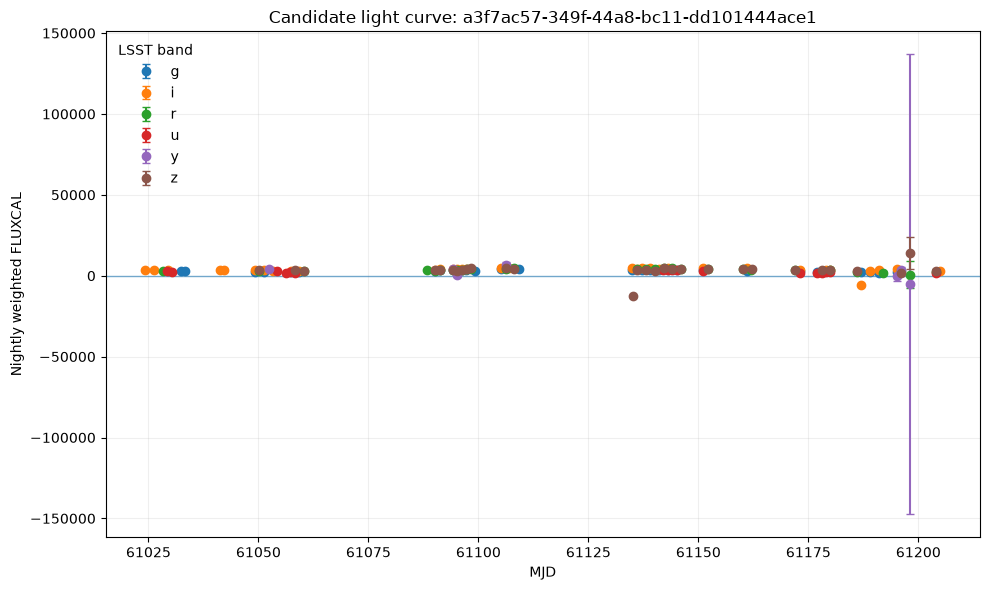

In [76]:
def plot_nightly_lightcurve(nightly, snid=None):
    if len(nightly) == 0:
        print("No clean nightly photometry to plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))

    for current_band in np.unique(nightly["BAND"]):
        use = nightly["BAND"] == current_band
        order = np.argsort(nightly["MJD"][use])
        ax.errorbar(
            nightly["MJD"][use][order],
            nightly["FLUX"][use][order],
            yerr=nightly["FLUXERR"][use][order],
            fmt="o",
            capsize=3,
            label=current_band,
        )

    ax.axhline(0, linewidth=1, alpha=0.6)
    ax.set_xlabel("MJD")
    ax.set_ylabel("Nightly weighted FLUXCAL")
    ax.set_title(f"Candidate light curve: {snid}" if snid else "Nightly light curve")
    ax.legend(title="LSST band", frameon=False)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()


plot_nightly_lightcurve(best_nightly, best_snid)

In [77]:
# Comparison to unmasked version

good = photometry_mask(best_lc)
detect = photometry_mask(best_lc, detections_only=True)

inspection = pd.DataFrame({
    "MJD": np.asarray(best_lc["MJD"], dtype=float),
    "BAND": np.char.strip(np.asarray(best_lc["BAND"]).astype(str)),
    "FLUXCAL": np.asarray(best_lc["FLUXCAL"], dtype=float),
    "FLUXCALERR": np.asarray(best_lc["FLUXCALERR"], dtype=float),
    "PHOTFLAG": np.asarray(best_lc["PHOTFLAG"], dtype=int),
    "GOOD": good,
    "DETECTION": detect,
})

display(inspection)

,MJD,BAND,FLUXCAL,FLUXCALERR,PHOTFLAG,GOOD,DETECTION
0,61024.2948,i,3800.199951,98.334999,1,True,True
1,61026.2137,i,3795.199951,317.170013,1,True,True
2,61028.3266,r,3106.199951,57.818001,1,True,True
3,61029.3241,u,2729.500000,125.769997,1,True,True
4,61029.3311,g,2677.300049,154.949997,1,True,True
...,...,...,...,...,...,...,...
144,61198.0024,z,13864.000000,9813.500000,0,True,False
145,61204.0172,u,1563.000000,1060.400024,0,True,False
146,61204.0213,r,2193.399902,744.479980,0,True,False
147,61204.0256,z,2992.800049,1126.800049,0,True,False


### Refinements of Cuts

In [86]:
def science_quality_mask(lc, min_snr=3.0):
    """Select clean photometry with |FLUXCAL| / FLUXCALERR >= min_snr."""
    good = photometry_mask(lc)

    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)

    snr = np.zeros(len(lc), dtype=float)
    snr[good] = np.abs(flux[good]) / fluxerr[good]

    return good & (snr >= min_snr)
    
def positive_detection_mask(lc, min_snr=3.0):
    """
    Select clean, positive, high-S/N photometric measurements.
    """
    good = photometry_mask(lc)

    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)

    snr = np.zeros(len(lc), dtype=float)
    snr[good] = flux[good] / fluxerr[good]

    return good & (snr >= min_snr)

In [80]:
quality = science_quality_mask(best_lc, min_snr=3.0)

print("Total rows:", len(best_lc))
print("Basic clean rows:", photometry_mask(best_lc).sum())
print("High-S/N clean rows:", quality.sum())

Total rows: 149
Basic clean rows: 149
High-S/N clean rows: 138


In [81]:
test_df = pd.DataFrame({
    "MJD": np.asarray(best_lc["MJD"], dtype=float),
    "BAND": np.char.strip(np.asarray(best_lc["BAND"]).astype(str)),
    "FLUXCAL": np.asarray(best_lc["FLUXCAL"], dtype=float),
    "FLUXCALERR": np.asarray(best_lc["FLUXCALERR"], dtype=float),
})

test_df["SNR"] = (
    np.abs(test_df["FLUXCAL"])
    / test_df["FLUXCALERR"]
)

test_df["BASIC_GOOD"] = photometry_mask(best_lc)
test_df["SCIENCE_QUALITY"] = quality

display(test_df)

,MJD,BAND,FLUXCAL,FLUXCALERR,SNR,BASIC_GOOD,SCIENCE_QUALITY
0,61024.2948,i,3800.199951,98.334999,38.645447,True,True
1,61026.2137,i,3795.199951,317.170013,11.965822,True,True
2,61028.3266,r,3106.199951,57.818001,53.723752,True,True
3,61029.3241,u,2729.500000,125.769997,21.702314,True,True
4,61029.3311,g,2677.300049,154.949997,17.278478,True,True
...,...,...,...,...,...,...,...
144,61198.0024,z,13864.000000,9813.500000,1.412748,True,False
145,61204.0172,u,1563.000000,1060.400024,1.473972,True,False
146,61204.0213,r,2193.399902,744.479980,2.946217,True,False
147,61204.0256,z,2992.800049,1126.800049,2.656017,True,False


In [82]:
def make_quality_nightly_lightcurve(lc, min_snr=3.0):
    """
    Inverse-variance combine high-quality measurements
    by integer MJD and band.
    """
    good = science_quality_mask(lc, min_snr=min_snr)

    if not np.any(good):
        return np.array([], dtype=NIGHTLY_DTYPE)

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)

    night_id = np.floor(mjd).astype(int)

    records = []

    for current_band in np.unique(band[good]):
        band_good = good & (band == current_band)

        for night in np.unique(night_id[band_good]):
            use = band_good & (night_id == night)

            weights = 1.0 / fluxerr[use]**2
            wsum = weights.sum()

            records.append((
                np.sum(weights * mjd[use]) / wsum,
                current_band,
                np.sum(weights * flux[use]) / wsum,
                np.sqrt(1.0 / wsum),
                int(use.sum()),
            ))

    return np.array(records, dtype=NIGHTLY_DTYPE)

In [83]:
best_nightly_quality = make_quality_nightly_lightcurve(
    best_lc,
    min_snr=3.0
)

In [84]:
print("Original nightly points:", len(best_nightly))
print("High-S/N nightly points:", len(best_nightly_quality))

Original nightly points: 149
High-S/N nightly points: 138


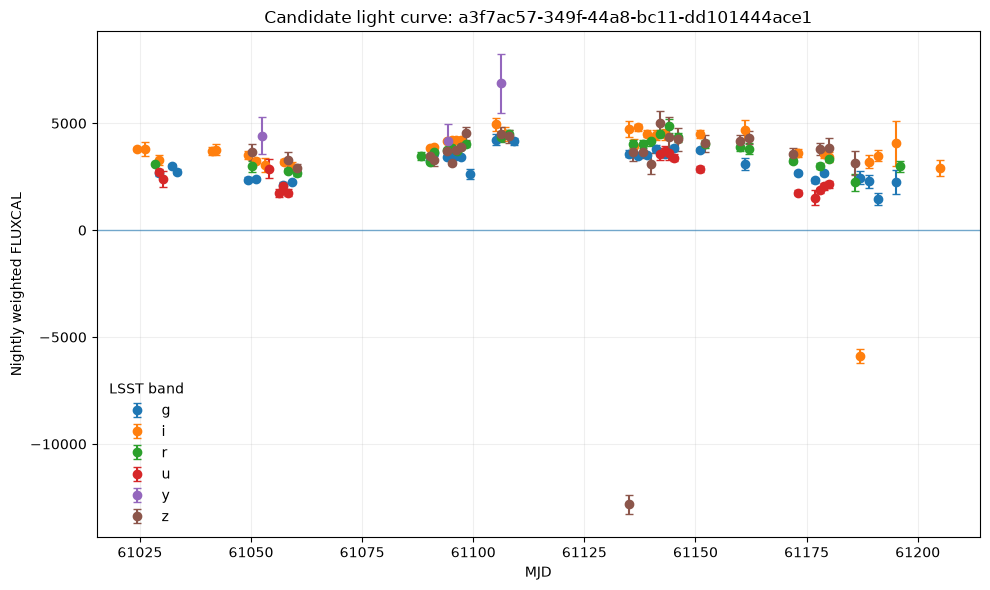

In [85]:
plot_nightly_lightcurve(
    best_nightly_quality,
    best_snid
)

In [87]:
basic_good = photometry_mask(best_lc)
science_good = science_quality_mask(best_lc, min_snr=3.0)
positive_good = positive_detection_mask(best_lc, min_snr=3.0)

print("Raw rows:", len(best_lc))
print("Basic good:", basic_good.sum())
print("Science quality |S/N| >= 3:", science_good.sum())
print("Positive S/N >= 3:", positive_good.sum())

Raw rows: 149
Basic good: 149
Science quality |S/N| >= 3: 138
Positive S/N >= 3: 136


In [88]:
flux = np.asarray(best_lc["FLUXCAL"], dtype=float)
fluxerr = np.asarray(best_lc["FLUXCALERR"], dtype=float)
mjd = np.asarray(best_lc["MJD"], dtype=float)
band = np.char.strip(np.asarray(best_lc["BAND"]).astype(str))

snr = flux / fluxerr

negative_significant = science_good & (snr < -3)

negative_df = pd.DataFrame({
    "MJD": mjd[negative_significant],
    "BAND": band[negative_significant],
    "FLUXCAL": flux[negative_significant],
    "FLUXCALERR": fluxerr[negative_significant],
    "SNR": snr[negative_significant],
})

display(negative_df)

,MJD,BAND,FLUXCAL,FLUXCALERR,SNR
0,61135.0433,z,-12831.000000,442.980011,-28.965190
1,61186.9812,i,-5881.399902,336.730011,-17.466218


In [89]:
def make_positive_nightly_lightcurve(lc, min_snr=3.0):
    good = positive_detection_mask(lc, min_snr=min_snr)

    if not np.any(good):
        return np.array([], dtype=NIGHTLY_DTYPE)

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)

    night_id = np.floor(mjd).astype(int)

    records = []

    for current_band in np.unique(band[good]):
        band_good = good & (band == current_band)

        for night in np.unique(night_id[band_good]):
            use = band_good & (night_id == night)

            weights = 1.0 / fluxerr[use]**2
            wsum = weights.sum()

            records.append((
                np.sum(weights * mjd[use]) / wsum,
                current_band,
                np.sum(weights * flux[use]) / wsum,
                np.sqrt(1.0 / wsum),
                int(use.sum()),
            ))

    return np.array(records, dtype=NIGHTLY_DTYPE)

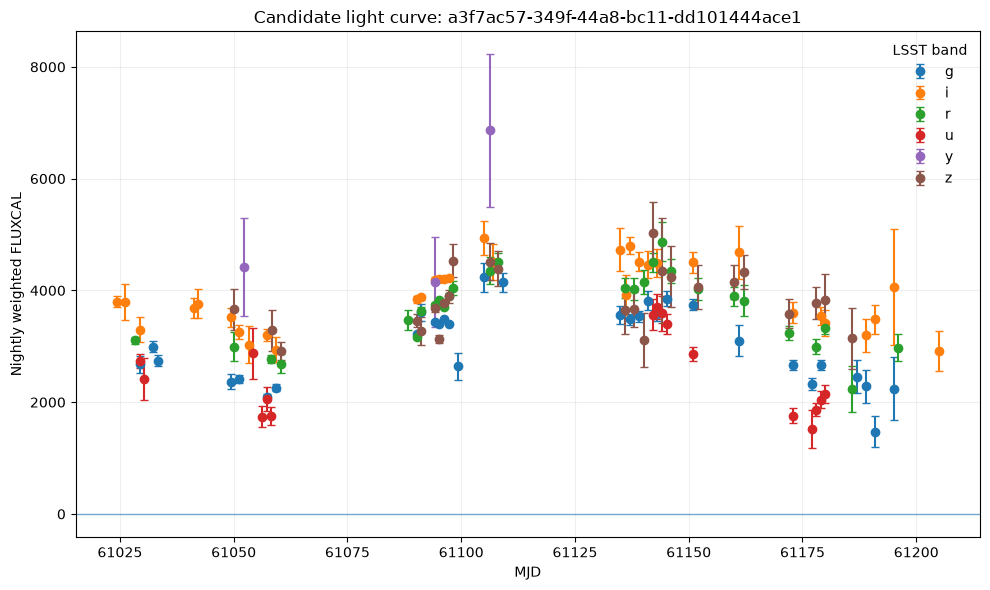

In [90]:
best_nightly_positive = make_positive_nightly_lightcurve(
    best_lc,
    min_snr=3.0
)

plot_nightly_lightcurve(
    best_nightly_positive,
    best_snid
)

### Specific SN lc cuts (exploratory):

In [91]:
def transient_metrics(lc, min_snr=3.0):
    good = photometry_mask(lc)
    pos = positive_detection_mask(lc, min_snr=min_snr)

    mjd = np.asarray(lc["MJD"], dtype=float)
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)

    if not np.any(good):
        return {
            "N_POS": 0,
            "N_POS_BANDS": 0,
            "N_POS_NIGHTS": 0,
            "PEAK_FLUX": np.nan,
            "BASELINE_FLUX": np.nan,
            "AMPLITUDE": np.nan,
            "PEAK_SNR": np.nan,
            "EVENT_SPAN": np.nan,
        }

    # Positive high-S/N measurements
    n_pos = int(pos.sum())
    n_pos_bands = len(np.unique(band[pos])) if np.any(pos) else 0
    n_pos_nights = (
        len(np.unique(np.floor(mjd[pos]).astype(int)))
        if np.any(pos) else 0
    )

    # Peak measurement
    if np.any(pos):
        peak_idx = np.argmax(flux[pos])
        peak_flux = flux[pos][peak_idx]
        peak_mjd = mjd[pos][peak_idx]
        peak_snr = np.max(flux[pos] / fluxerr[pos])
    else:
        peak_flux = np.nan
        peak_mjd = np.nan
        peak_snr = np.nan

    # Simple baseline: median of clean measurements
    baseline_flux = np.median(flux[good])

    amplitude = (
        peak_flux - baseline_flux
        if np.isfinite(peak_flux)
        else np.nan
    )

    # Duration covered by significant positive measurements
    if np.sum(pos) >= 2:
        event_span = mjd[pos].max() - mjd[pos].min()
    else:
        event_span = np.nan

    return {
        "N_POS": n_pos,
        "N_POS_BANDS": n_pos_bands,
        "N_POS_NIGHTS": n_pos_nights,
        "PEAK_FLUX": peak_flux,
        "BASELINE_FLUX": baseline_flux,
        "AMPLITUDE": amplitude,
        "PEAK_SNR": peak_snr,
        "EVENT_SPAN": event_span,
    }


In [93]:
transient_rows = []

for idx in range(len(head_data)):
    head_row = head_data[idx]

    lc = get_lightcurve(head_row)
    metrics = transient_metrics(lc, min_snr=3.0)

    transient_rows.append({
        "HEAD_INDEX": idx,
        "SNID": str(head_row["SNID"]),
        **metrics,
    })

transient_summary = pd.DataFrame(transient_rows)

In [94]:
# Explore dist of cuts

display(
    transient_summary[
        [
            "N_POS",
            "N_POS_BANDS",
            "N_POS_NIGHTS",
            "AMPLITUDE",
            "PEAK_SNR",
            "EVENT_SPAN",
        ]
    ].describe()
)

,N_POS,N_POS_BANDS,N_POS_NIGHTS,AMPLITUDE,PEAK_SNR,EVENT_SPAN
count,51000.000000,51000.000000,51000.000000,1.220400e+04,12204.000000,6532.000000
mean,1.079137,0.370137,0.628980,7.137237e+03,22.531003,27.927161
std,7.095465,0.803358,2.260074,4.034602e+04,54.663706,42.849975
min,0.000000,0.000000,0.000000,-4.530500e+02,3.002405,0.000100
25%,0.000000,0.000000,0.000000,0.000000e+00,7.387261,3.981375
50%,0.000000,0.000000,0.000000,6.218250e+02,11.426524,9.948950
75%,0.000000,0.000000,0.000000,2.636770e+03,18.684036,38.830600
max,594.000000,6.000000,63.000000,1.571460e+06,2057.171487,250.199200


In [95]:
transient_mask = (
    (transient_summary["N_POS"] >= 5)
    & (transient_summary["N_POS_BANDS"] >= 2)
    & (transient_summary["N_POS_NIGHTS"] >= 4)
    & (transient_summary["PEAK_SNR"] >= 5)
    & (transient_summary["AMPLITUDE"] > 0)
)

In [96]:
transient_candidates = (
    transient_summary.loc[transient_mask]
    .sort_values(
        [
            "PEAK_SNR",
            "AMPLITUDE",
            "N_POS_NIGHTS",
            "N_POS_BANDS",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

Best transient candidate
------------------------
SNID: bd0b7764-c21c-47f8-a4f5-fd87e7238898
HEAD index: 37136


,HEAD_INDEX,SNID,N_POS,N_POS_BANDS,N_POS_NIGHTS,PEAK_FLUX,BASELINE_FLUX,AMPLITUDE,PEAK_SNR,EVENT_SPAN
0,37136,bd0b7764-c21c-47f8-a4f5-fd87e7238898,46,6,27,303260.0,-37676.0,340936.0,2057.171487,174.7015


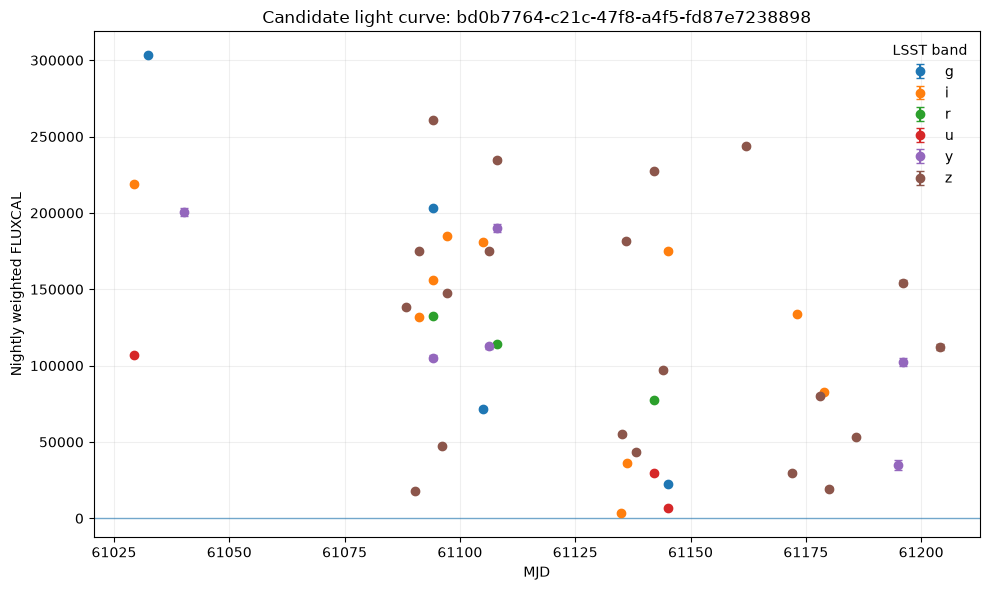

In [97]:
best_transient = transient_candidates.iloc[0]

best_idx = int(best_transient["HEAD_INDEX"])
best_snid = best_transient["SNID"]

best_head_row = head_data[best_idx]
best_transient_lc = get_lightcurve(best_head_row)

best_transient_nightly = make_positive_nightly_lightcurve(
    best_transient_lc,
    min_snr=3.0,
)

print("Best transient candidate")
print("------------------------")
print("SNID:", best_snid)
print("HEAD index:", best_idx)

display(best_transient.to_frame().T)

plot_nightly_lightcurve(
    best_transient_nightly,
    best_snid,
)


Rank 1: bd0b7764-c21c-47f8-a4f5-fd87e7238898
N_POS=46, N_POS_NIGHTS=27, N_POS_BANDS=6, PEAK_SNR=2057.2, AMPLITUDE=340936.0


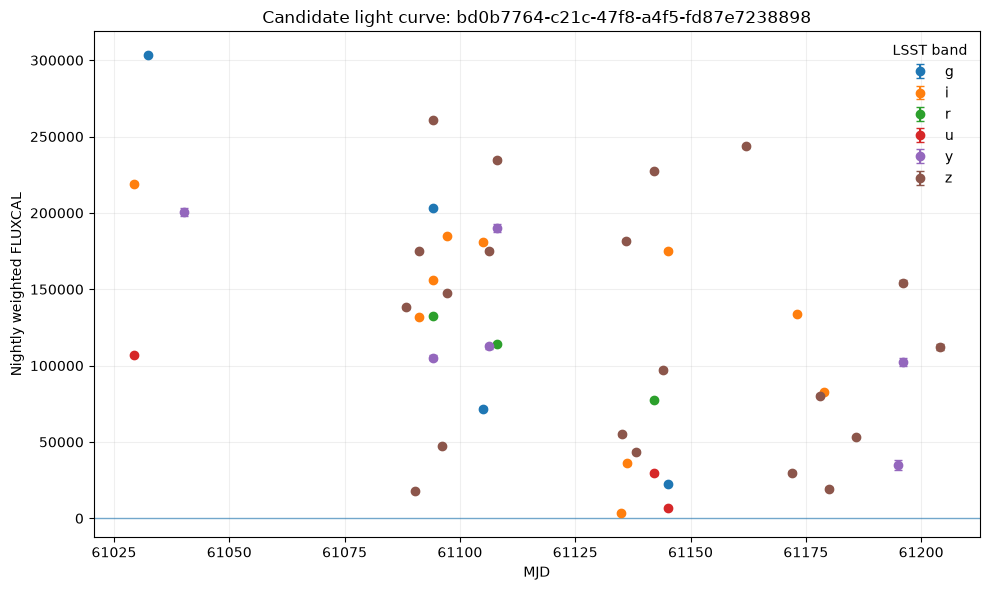


Rank 2: dbce04ab-1a55-4d43-abb2-b24a53e4fb2a
N_POS=88, N_POS_NIGHTS=47, N_POS_BANDS=4, PEAK_SNR=1652.3, AMPLITUDE=56062.0


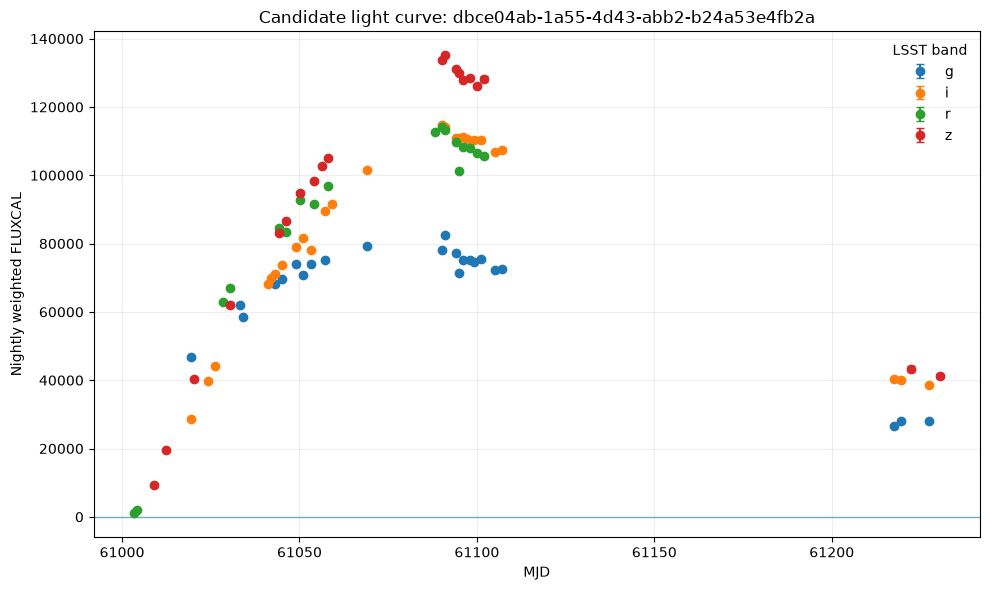


Rank 3: 42c4d994-fd32-46c1-8099-3b39ea5eb532
N_POS=53, N_POS_NIGHTS=34, N_POS_BANDS=6, PEAK_SNR=1326.4, AMPLITUDE=52104.9


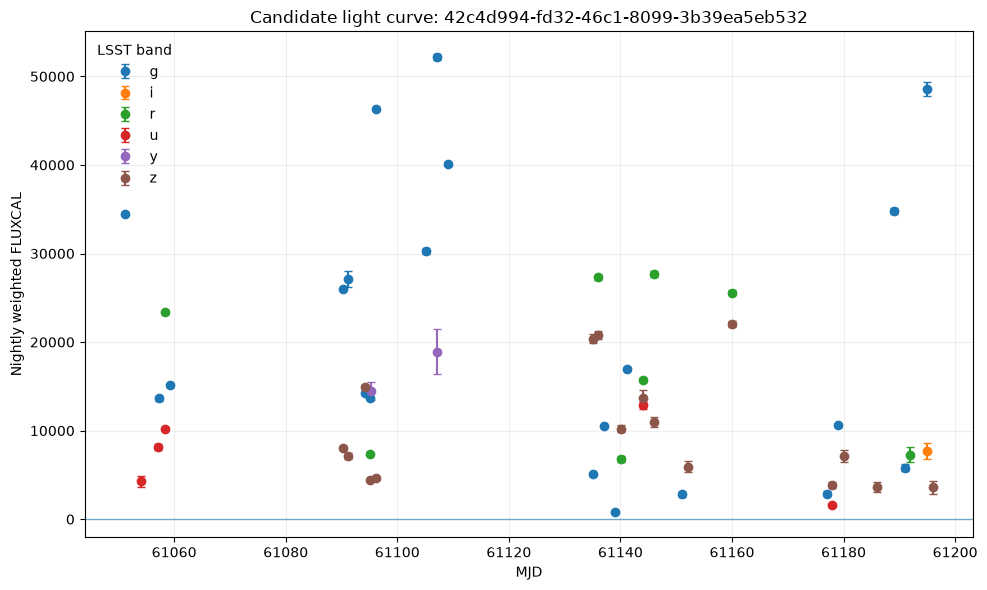


Rank 4: a8f9b606-293f-473b-9ca2-371b8d9ff71e
N_POS=23, N_POS_NIGHTS=8, N_POS_BANDS=5, PEAK_SNR=951.8, AMPLITUDE=57390.0


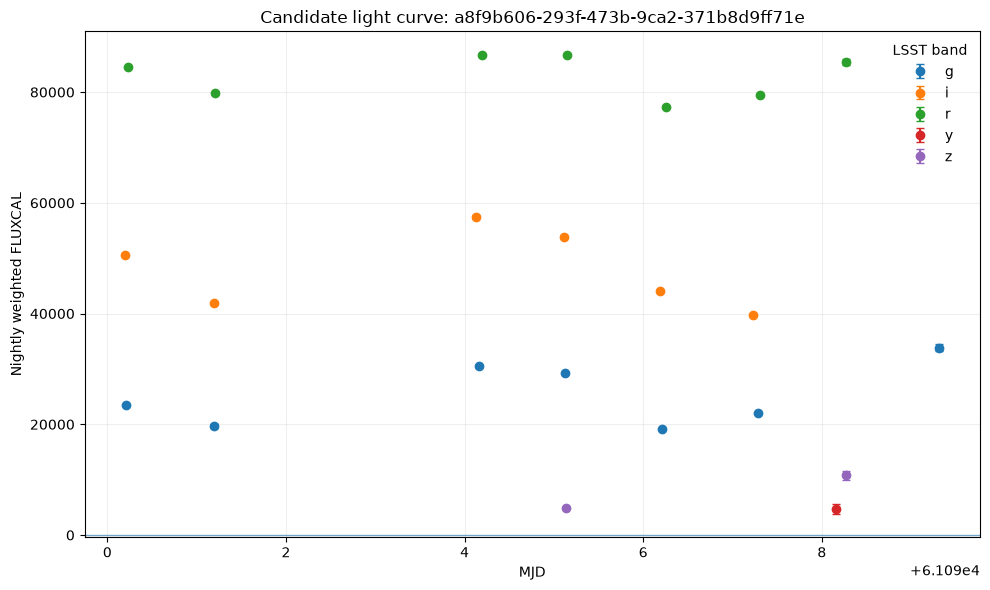


Rank 5: 8f156832-1cb6-49e8-a3d4-b5bf27fc0ba1
N_POS=29, N_POS_NIGHTS=23, N_POS_BANDS=4, PEAK_SNR=797.9, AMPLITUDE=105205.0


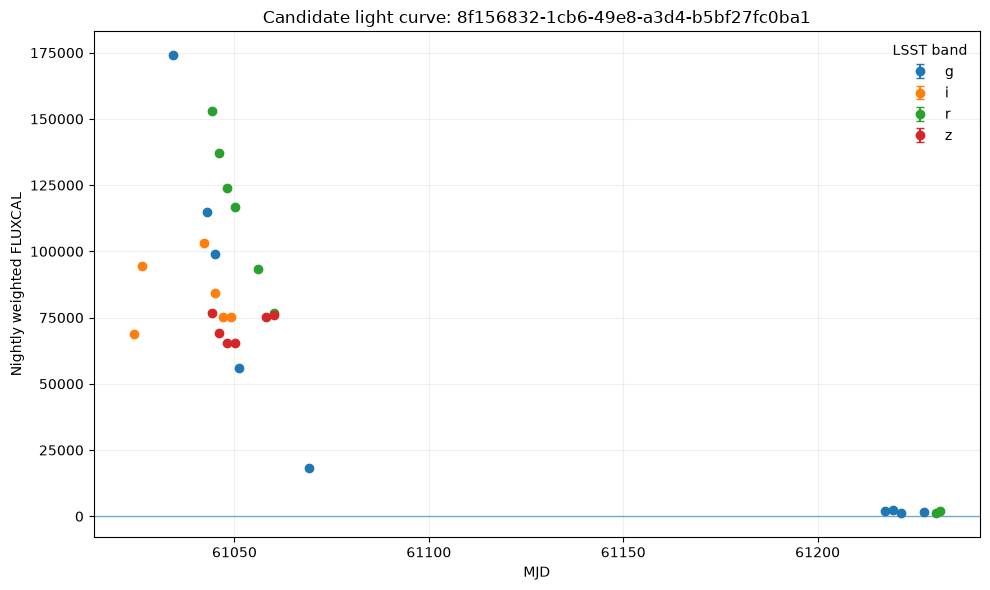

In [98]:
for rank in range(min(5, len(transient_candidates))):
    candidate = transient_candidates.iloc[rank]

    idx = int(candidate["HEAD_INDEX"])
    snid = candidate["SNID"]

    lc = get_lightcurve(head_data[idx])

    nightly = make_positive_nightly_lightcurve(
        lc,
        min_snr=3.0,
    )

    print(f"\nRank {rank + 1}: {snid}")
    print(
        f"N_POS={candidate['N_POS']}, "
        f"N_POS_NIGHTS={candidate['N_POS_NIGHTS']}, "
        f"N_POS_BANDS={candidate['N_POS_BANDS']}, "
        f"PEAK_SNR={candidate['PEAK_SNR']:.1f}, "
        f"AMPLITUDE={candidate['AMPLITUDE']:.1f}"
    )

    plot_nightly_lightcurve(nightly, snid)
